In [37]:
!pip install pandas
!pip install numpy
!pip install matplotlib
!pip install seaborn
!pip install scikit-learn
!pip install xgboost
!pip install lightgbm
!pip install catboost
!pip install joblib
!pip install streamlit

In [38]:
import pandas as pd

train_values = pd.read_csv("../data/train_values.csv")
train_labels = pd.read_csv("../data/train_labels.csv")

df = train_values.merge(train_labels, on='building_id')

In [39]:
print(df.shape)

print(df.columns)

print(df.dtypes)

df.sample(5)

(260601, 40)
Index(['building_id', 'geo_level_1_id', 'geo_level_2_id', 'geo_level_3_id',
       'count_floors_pre_eq', 'age', 'area_percentage', 'height_percentage',
       'land_surface_condition', 'foundation_type', 'roof_type',
       'ground_floor_type', 'other_floor_type', 'position',
       'plan_configuration', 'has_superstructure_adobe_mud',
       'has_superstructure_mud_mortar_stone', 'has_superstructure_stone_flag',
       'has_superstructure_cement_mortar_stone',
       'has_superstructure_mud_mortar_brick',
       'has_superstructure_cement_mortar_brick', 'has_superstructure_timber',
       'has_superstructure_bamboo', 'has_superstructure_rc_non_engineered',
       'has_superstructure_rc_engineered', 'has_superstructure_other',
       'legal_ownership_status', 'count_families', 'has_secondary_use',
       'has_secondary_use_agriculture', 'has_secondary_use_hotel',
       'has_secondary_use_rental', 'has_secondary_use_institution',
       'has_secondary_use_school', 'has_se

,building_id,geo_level_1_id,geo_level_2_id,geo_level_3_id,count_floors_pre_eq,age,area_percentage,height_percentage,land_surface_condition,foundation_type,...,has_secondary_use_hotel,has_secondary_use_rental,has_secondary_use_institution,has_secondary_use_school,has_secondary_use_industry,has_secondary_use_health_post,has_secondary_use_gov_office,has_secondary_use_use_police,has_secondary_use_other,damage_grade
30409,897639,8,178,9925,1,25,8,2,t,r,...,0,0,0,0,0,0,0,0,0,3
141794,473639,11,883,4530,2,60,3,5,t,r,...,0,0,0,0,0,0,0,0,0,2
50171,781192,3,720,5016,3,0,14,7,t,r,...,0,0,0,0,0,0,0,0,0,2
171028,817219,26,1050,8526,1,0,24,3,t,u,...,0,1,0,0,0,0,0,0,0,1
237087,220085,12,650,2405,2,25,6,4,t,r,...,0,0,0,0,0,0,0,0,0,2


In [40]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Rows: 260601
Columns: 40


Missing Values

In [41]:
df.isnull().sum().sort_values(ascending=False)

building_id                               0
geo_level_1_id                            0
geo_level_2_id                            0
geo_level_3_id                            0
count_floors_pre_eq                       0
age                                       0
area_percentage                           0
height_percentage                         0
land_surface_condition                    0
foundation_type                           0
roof_type                                 0
ground_floor_type                         0
other_floor_type                          0
position                                  0
plan_configuration                        0
has_superstructure_adobe_mud              0
has_superstructure_mud_mortar_stone       0
has_superstructure_stone_flag             0
has_superstructure_cement_mortar_stone    0
has_superstructure_mud_mortar_brick       0
has_superstructure_cement_mortar_brick    0
has_superstructure_timber                 0
has_superstructure_bamboo       

In [42]:
df.duplicated().sum() #duplicate Rows


np.int64(0)

In [43]:
df.describe().T #statistical Summary

,count,mean,std,min,25%,50%,75%,max
building_id,260601.0,525675.482773,304544.999032,4.0,261190.0,525757.0,789762.0,1052934.0
geo_level_1_id,260601.0,13.900353,8.033617,0.0,7.0,12.0,21.0,30.0
geo_level_2_id,260601.0,701.074685,412.710734,0.0,350.0,702.0,1050.0,1427.0
geo_level_3_id,260601.0,6257.876148,3646.369645,0.0,3073.0,6270.0,9412.0,12567.0
count_floors_pre_eq,260601.0,2.129723,0.727665,1.0,2.0,2.0,2.0,9.0
age,260601.0,26.535029,73.565937,0.0,10.0,15.0,30.0,995.0
area_percentage,260601.0,8.018051,4.392231,1.0,5.0,7.0,9.0,100.0
height_percentage,260601.0,5.434365,1.918418,2.0,4.0,5.0,6.0,32.0
has_superstructure_adobe_mud,260601.0,0.088645,0.284231,0.0,0.0,0.0,0.0,1.0
has_superstructure_mud_mortar_stone,260601.0,0.761935,0.425900,0.0,1.0,1.0,1.0,1.0


In [44]:
for col in df.columns:
    print(col, df[col].nunique())

building_id 260601
geo_level_1_id 31
geo_level_2_id 1414
geo_level_3_id 11595
count_floors_pre_eq 9
age 42
area_percentage 84
height_percentage 27
land_surface_condition 3
foundation_type 5
roof_type 3
ground_floor_type 5
other_floor_type 4
position 4
plan_configuration 10
has_superstructure_adobe_mud 2
has_superstructure_mud_mortar_stone 2
has_superstructure_stone_flag 2
has_superstructure_cement_mortar_stone 2
has_superstructure_mud_mortar_brick 2
has_superstructure_cement_mortar_brick 2
has_superstructure_timber 2
has_superstructure_bamboo 2
has_superstructure_rc_non_engineered 2
has_superstructure_rc_engineered 2
has_superstructure_other 2
legal_ownership_status 4
count_families 10
has_secondary_use 2
has_secondary_use_agriculture 2
has_secondary_use_hotel 2
has_secondary_use_rental 2
has_secondary_use_institution 2
has_secondary_use_school 2
has_secondary_use_industry 2
has_secondary_use_health_post 2
has_secondary_use_gov_office 2
has_secondary_use_use_police 2
has_secondary_use_

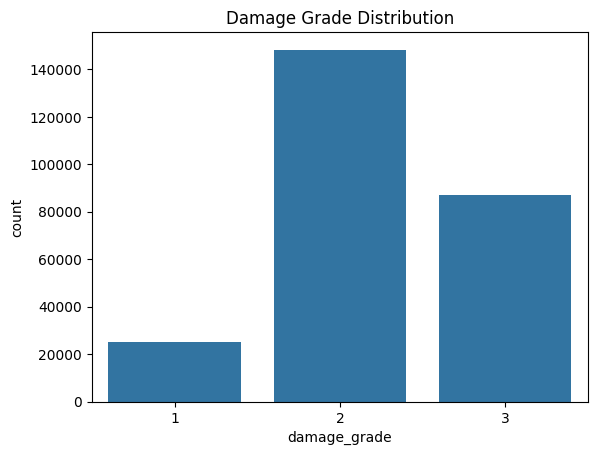

In [45]:
#Numerical Feature Analysis
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(
    x='damage_grade',
    data=df
)

plt.title("Damage Grade Distribution")
plt.show()

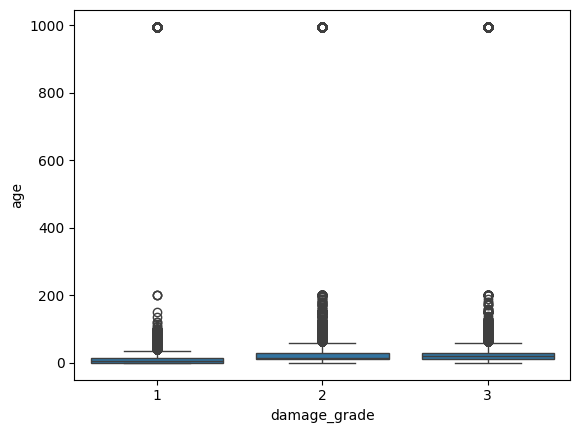

In [46]:
# Age vs Damage
sns.boxplot(
    x='damage_grade',
    y='age',
    data=df
)
plt.show()

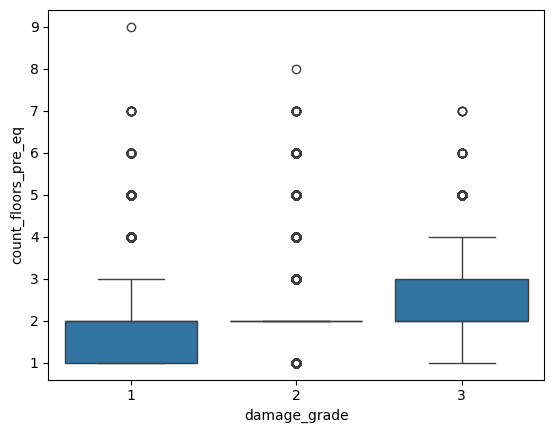

In [47]:
#floor vs Damage
sns.boxplot(
    x='damage_grade',
    y='count_floors_pre_eq',
    data=df
)
plt.show()

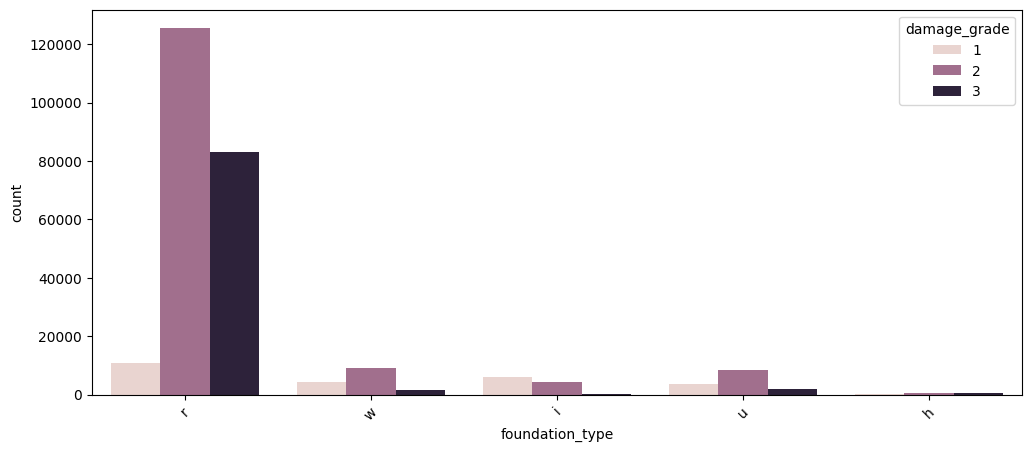

In [48]:
#Foundation Type Analysis

plt.figure(figsize=(12,5))

sns.countplot(
    x='foundation_type',
    hue='damage_grade',
    data=df
)

plt.xticks(rotation=45)
plt.show()

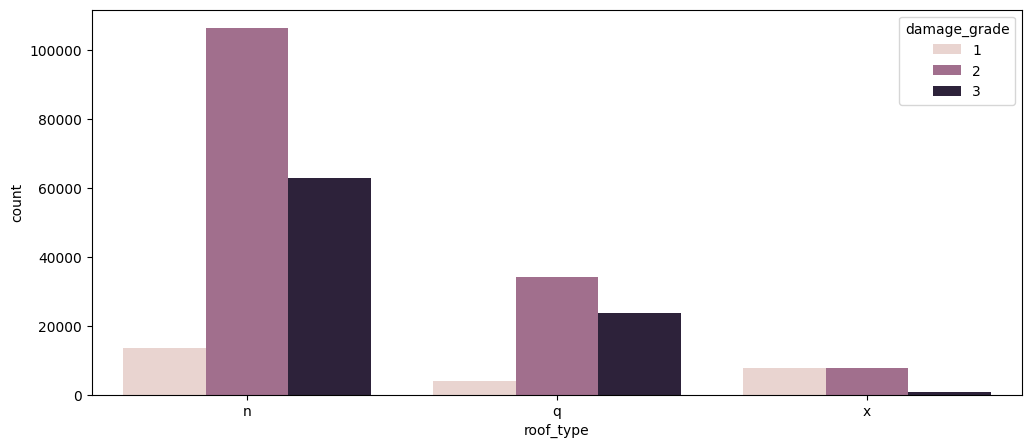

In [49]:
#Roof Type Analysis 

plt.figure(figsize=(12,5))

sns.countplot(
    x='roof_type',
    hue='damage_grade',
    data=df
)

plt.show()

In [50]:
#correlation Heatmap

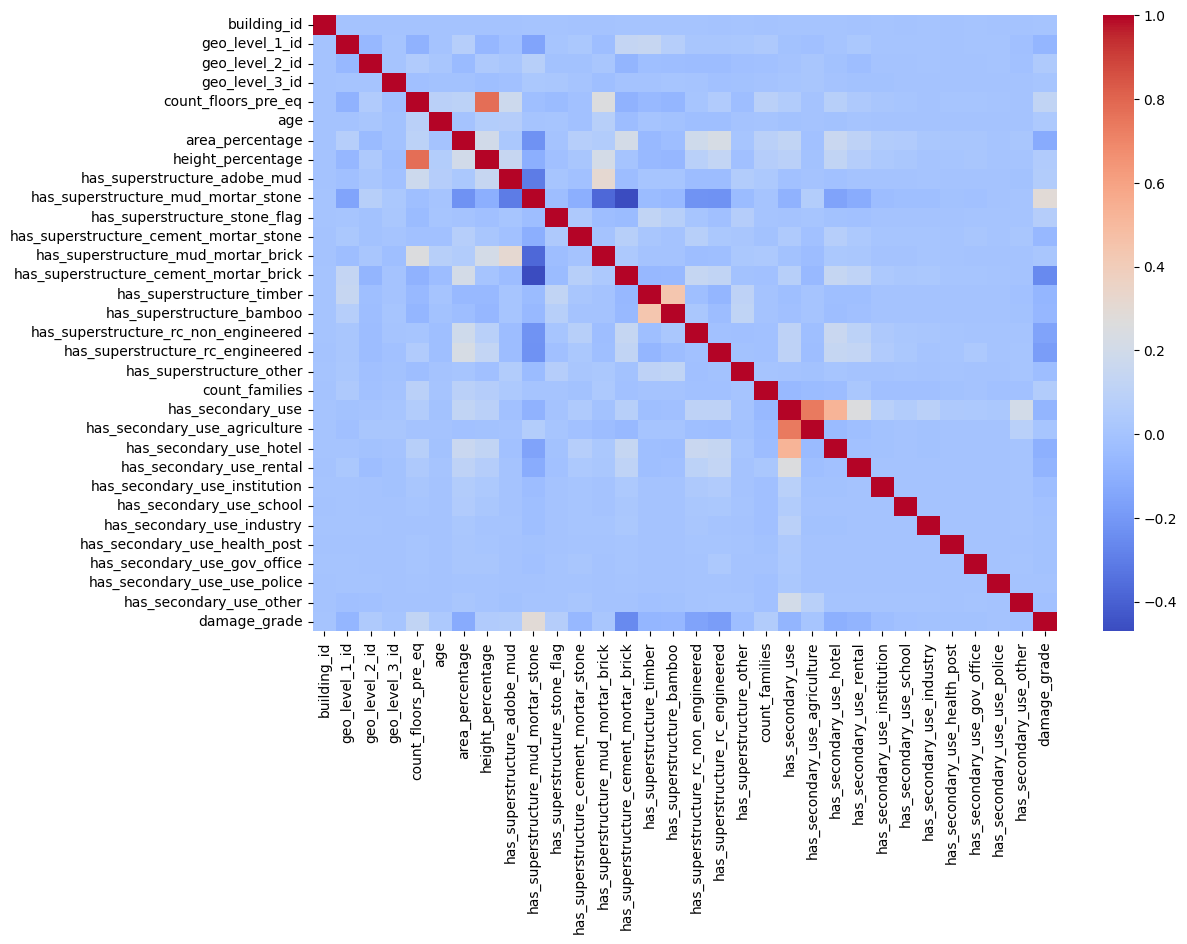

In [51]:
numeric_df = df.select_dtypes(
    include=['int64','float64']
)

plt.figure(figsize=(12,8))

sns.heatmap(
    numeric_df.corr(),
    cmap='coolwarm'
)

plt.show()

Data Cleaning

In [52]:
# Missing Value Handling
for col in df.columns:
    if df[col].dtype == 'object' or str(df[col].dtype) == 'category':
        df[col] = df[col].fillna(df[col].mode()[0])
    elif pd.api.types.is_numeric_dtype(df[col]):
        df[col] = df[col].fillna(df[col].median())

print("Missing values after treatment:")
print(df.isnull().sum().sum())

Missing values after treatment:
0


In [53]:
#Remove Duplicates
df.drop_duplicates(inplace=True)

In [54]:
num_cols = df.select_dtypes(
    include=['int64', 'float64']
).columns

print(num_cols)

Index(['building_id', 'geo_level_1_id', 'geo_level_2_id', 'geo_level_3_id',
       'count_floors_pre_eq', 'age', 'area_percentage', 'height_percentage',
       'has_superstructure_adobe_mud', 'has_superstructure_mud_mortar_stone',
       'has_superstructure_stone_flag',
       'has_superstructure_cement_mortar_stone',
       'has_superstructure_mud_mortar_brick',
       'has_superstructure_cement_mortar_brick', 'has_superstructure_timber',
       'has_superstructure_bamboo', 'has_superstructure_rc_non_engineered',
       'has_superstructure_rc_engineered', 'has_superstructure_other',
       'count_families', 'has_secondary_use', 'has_secondary_use_agriculture',
       'has_secondary_use_hotel', 'has_secondary_use_rental',
       'has_secondary_use_institution', 'has_secondary_use_school',
       'has_secondary_use_industry', 'has_secondary_use_health_post',
       'has_secondary_use_gov_office', 'has_secondary_use_use_police',
       'has_secondary_use_other', 'damage_grade'],
      dt

In [55]:
#Outlier Treatment
for col in num_cols:

    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5*IQR
    upper = Q3 + 1.5*IQR

    df[col] = df[col].clip(lower, upper)

Feature Engineering


Age Group

In [56]:

df['age_group'] = pd.cut(
    df['age'],
    bins=[0, 10, 30, 50, 1000],
    labels=['New', 'Medium', 'Old', 'Very_Old']
)


In [57]:
df['area_group'] = pd.qcut(
    df['area_percentage'],
    q=4,
    labels=['Small', 'Medium', 'Large', 'Huge']
)

In [58]:
import numpy as np

df['height_per_floor'] = df['height_percentage'] / df['count_floors_pre_eq']

# Replace infinities and fill NaN
df['height_per_floor'] = df['height_per_floor'].replace([np.inf, -np.inf], 0)
df['height_per_floor'] = df['height_per_floor'].fillna(0)

Phase 8: Prepare X and y

In [68]:
X = df.drop(
    columns=['damage_grade']
)

y = df['damage_grade'] - 1

In [69]:
print(X.dtypes)

building_id                                  int64
geo_level_1_id                               int64
geo_level_2_id                               int64
geo_level_3_id                               int64
count_floors_pre_eq                          int64
age                                          int64
area_percentage                              int64
height_percentage                            int64
land_surface_condition                      object
foundation_type                             object
roof_type                                   object
ground_floor_type                           object
other_floor_type                            object
position                                    object
plan_configuration                          object
has_superstructure_adobe_mud                 int64
has_superstructure_mud_mortar_stone          int64
has_superstructure_stone_flag                int64
has_superstructure_cement_mortar_stone       int64
has_superstructure_mud_mortar_b

Identify Numerical and Categorical Columns


In [70]:
cat_cols = X.select_dtypes(
    include=['object', 'category']
).columns.tolist()

num_cols = X.select_dtypes(
    include=['int64', 'float64']
).columns.tolist()

print("Categorical Columns")
print(cat_cols)

print()

print("Numerical Columns")
print(num_cols)

Categorical Columns
['land_surface_condition', 'foundation_type', 'roof_type', 'ground_floor_type', 'other_floor_type', 'position', 'plan_configuration', 'legal_ownership_status', 'age_group', 'area_group']

Numerical Columns
['building_id', 'geo_level_1_id', 'geo_level_2_id', 'geo_level_3_id', 'count_floors_pre_eq', 'age', 'area_percentage', 'height_percentage', 'has_superstructure_adobe_mud', 'has_superstructure_mud_mortar_stone', 'has_superstructure_stone_flag', 'has_superstructure_cement_mortar_stone', 'has_superstructure_mud_mortar_brick', 'has_superstructure_cement_mortar_brick', 'has_superstructure_timber', 'has_superstructure_bamboo', 'has_superstructure_rc_non_engineered', 'has_superstructure_rc_engineered', 'has_superstructure_other', 'count_families', 'has_secondary_use', 'has_secondary_use_agriculture', 'has_secondary_use_hotel', 'has_secondary_use_rental', 'has_secondary_use_institution', 'has_secondary_use_school', 'has_secondary_use_industry', 'has_secondary_use_health_p

Preprocessing Pipeline

In [71]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler
preprocessor = ColumnTransformer(
    transformers=[

        (
            'num',
            StandardScaler(),
            num_cols
        ),

        (
            'cat',
            OneHotEncoder(
                handle_unknown='ignore'
            ),
            cat_cols
        )

    ]
)

  Train-Test Split
  

In [72]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

Baseline Model


In [73]:
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeClassifier
# Build the full pipeline
baseline = Pipeline([

    ('prep', preprocessor),

    ('model', DecisionTreeClassifier( random_state=42))

])

#train

baseline.fit(
    X_train,
    y_train
)

#predict
pred = baseline.predict(X_test)

Models to Train

In [74]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier,
    ExtraTreesClassifier,
    GradientBoostingClassifier
)
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

In [75]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=2000),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(),
    "Extra Trees": ExtraTreesClassifier(),
    "XGBoost": XGBClassifier(),
    "LightGBM": LGBMClassifier(),
    "CatBoost": CatBoostClassifier(verbose=0)
}

In [76]:
from sklearn.metrics import accuracy_score, classification_report
results = {}

for name, model in models.items():
    pipe = Pipeline([
        ('prep', preprocessor),
        ('model', model)
    ])
    pipe.fit(X_train, y_train)
    preds = pipe.predict(X_test)
    acc = accuracy_score(y_test, preds)
    results[name] = acc
    print(f"{name}: {acc:.4f}")  # ← inside the loop

print("\nBest model:", max(results, key=results.get))
best_model_name = max(results, key=results.get)

Logistic Regression: 0.5839
Decision Tree: 0.6442
Random Forest: 0.6886
Extra Trees: 0.6536
XGBoost: 0.7252
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.021404 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 940
[LightGBM] [Info] Number of data points in the train set: 208480, number of used features: 55
[LightGBM] [Info] Start training from score -2.339173
[LightGBM] [Info] Start training from score -0.564028
[LightGBM] [Info] Start training from score -1.094582


C:\Users\Harsha\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


LightGBM: 0.7104
CatBoost: 0.7221

Best model: XGBoost


Evaluation

In [77]:
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

In [78]:
print(
    "Accuracy:",
    accuracy_score(
        y_test,
        pred
    )
)

print(
    classification_report(
        y_test,
        pred
    )
)

Accuracy: 0.6440973887684427
              precision    recall  f1-score   support

           0       0.46      0.48      0.47      5025
           1       0.71      0.69      0.70     29652
           2       0.60      0.62      0.61     17444

    accuracy                           0.64     52121
   macro avg       0.59      0.60      0.59     52121
weighted avg       0.65      0.64      0.65     52121



In [79]:
print(
    confusion_matrix(
        y_test,
        pred
    )
)

[[ 2426  2206   393]
 [ 2510 20389  6753]
 [  383  6305 10756]]


In [80]:
models = {

    "Logistic Regression":
        LogisticRegression(max_iter=2000),

    "Decision Tree":
        DecisionTreeClassifier(),

    "Random Forest":
        RandomForestClassifier(),

    "Extra Trees":
        ExtraTreesClassifier(),

    "Gradient Boosting":
        GradientBoostingClassifier(),

    "XGBoost":
        XGBClassifier(),

    "LightGBM":
        LGBMClassifier(),

    "CatBoost":
        CatBoostClassifier(verbose=0)
}

Hyperparameter Tuning Example

In [81]:
from sklearn.model_selection import RandomizedSearchCV

# Using Random Forest as best model for tuning
best_pipeline = Pipeline([
    ('prep', preprocessor),
    ('model', RandomForestClassifier(random_state=42))
])

params = {
    "model__n_estimators": [100, 200, 300],
    "model__max_depth": [5, 10, 15, None],
    "model__min_samples_split": [2, 5, 10],
    "model__min_samples_leaf": [1, 2, 4]
}

search = RandomizedSearchCV(
    best_pipeline,
    params,
    n_iter=10,
    cv=3,
    scoring='accuracy',
    random_state=42,
    n_jobs=-1,
    verbose=1
)

search.fit(X_train, y_train)
best_model = search.best_estimator_
print("Best Params:", search.best_params_)
print("Best CV Score:", search.best_score_)

Fitting 3 folds for each of 10 candidates, totalling 30 fits
Best Params: {'model__n_estimators': 300, 'model__min_samples_split': 5, 'model__min_samples_leaf': 2, 'model__max_depth': None}
Best CV Score: 0.690229280230159


In [93]:
import joblib

joblib.dump(
    baseline,
    "earthquake_damage_model.pkl"
)

['earthquake_damage_model.pkl']

Prediction Function

In [94]:
def predict_damage(data):
    pred = best_model.predict(data)
    grade = pred + 1
    if grade == 1:
        return "Low Damage (Grade 1)"
    elif grade == 2:
        return "Medium Damage (Grade 2)"
    else:
        return "High Damage (Grade 3)"

# Test prediction on one sample
sample = X_test.iloc[[0]]
print("Prediction:", predict_damage(sample))
print("Actual:", y_test.iloc[0])

Prediction: Medium Damage (Grade 2)
Actual: 2


In [95]:
import os

print(os.path.exists("earthquake_damage_model.pkl"))

True


In [96]:
%whos

Variable                     Type                      Data/Info
----------------------------------------------------------------
CatBoostClassifier           type                      <class 'catboost.core.CatBoostClassifier'>
ColumnTransformer            ABCMeta                   <class 'sklearn.compose._<...>ormer.ColumnTransformer'>
ConfusionMatrixDisplay       type                      <class 'sklearn.metrics._<...>.ConfusionMatrixDisplay'>
DecisionTreeClassifier       ABCMeta                   <class 'sklearn.tree._cla<...>.DecisionTreeClassifier'>
ExtraTreesClassifier         ABCMeta                   <class 'sklearn.ensemble.<...>st.ExtraTreesClassifier'>
GradientBoostingClassifier   ABCMeta                   <class 'sklearn.ensemble.<...>dientBoostingClassifier'>
IQR                          float64                   1.0
LGBMClassifier               type                      <class 'lightgbm.sklearn.LGBMClassifier'>
LogisticRegression           type                      <class

In [97]:
dir()

['CatBoostClassifier',
 'ColumnTransformer',
 'ConfusionMatrixDisplay',
 'DecisionTreeClassifier',
 'ExtraTreesClassifier',
 'GradientBoostingClassifier',
 'IQR',
 'In',
 'LGBMClassifier',
 'LogisticRegression',
 'OneHotEncoder',
 'Out',
 'Pipeline',
 'Q1',
 'Q3',
 'RandomForestClassifier',
 'RandomizedSearchCV',
 'StandardScaler',
 'X',
 'XGBClassifier',
 'X_test',
 'X_train',
 '_',
 '_3',
 '_39',
 '_41',
 '_42',
 '_43',
 '_5',
 '_6',
 '_7',
 '_82',
 '_86',
 '_93',
 '__',
 '___',
 '__builtin__',
 '__builtins__',
 '__doc__',
 '__loader__',
 '__name__',
 '__package__',
 '__session__',
 '__spec__',
 '_dh',
 '_exit_code',
 '_i',
 '_i1',
 '_i10',
 '_i11',
 '_i12',
 '_i13',
 '_i14',
 '_i15',
 '_i16',
 '_i17',
 '_i18',
 '_i19',
 '_i2',
 '_i20',
 '_i21',
 '_i22',
 '_i23',
 '_i24',
 '_i25',
 '_i26',
 '_i27',
 '_i28',
 '_i29',
 '_i3',
 '_i30',
 '_i31',
 '_i32',
 '_i33',
 '_i34',
 '_i35',
 '_i36',
 '_i37',
 '_i38',
 '_i39',
 '_i4',
 '_i40',
 '_i41',
 '_i42',
 '_i43',
 '_i44',
 '_i45',
 '_i46',
 

In [98]:
import joblib

joblib.dump(
    baseline,
    "earthquake_damage_model.pkl"
)

print("Model Saved Successfully")

Model Saved Successfully


In [99]:
import joblib
import os

# Save final model
os.makedirs("../models", exist_ok=True)
joblib.dump(best_model, "../models/earthquake_damage_model.pkl")
joblib.dump(best_model, "earthquake_damage_model.pkl")
print("Best model saved successfully!")

Best model saved successfully!


## Step 9: Feature Importance Analysis

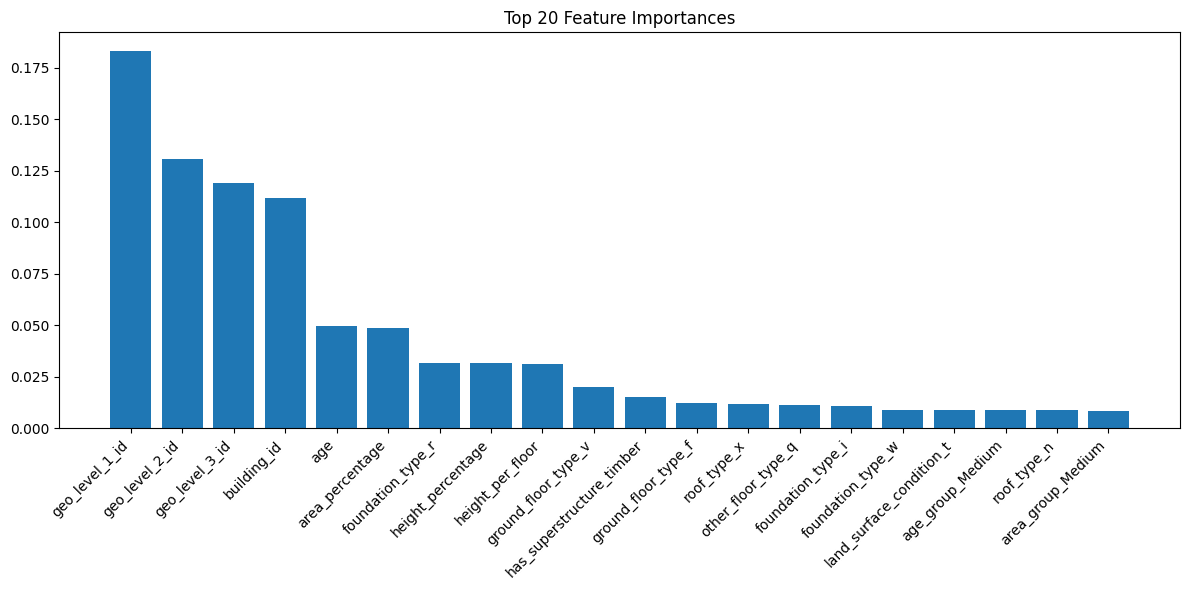

In [100]:
import matplotlib.pyplot as plt
import numpy as np

# Get feature importances from the Random Forest inside the pipeline
rf_model = best_model.named_steps['model']
ohe_cols = best_model.named_steps['prep'].transformers_[1][1].get_feature_names_out(cat_cols)
all_feature_names = list(num_cols) + list(ohe_cols)

importances = rf_model.feature_importances_
indices = np.argsort(importances)[::-1][:20]

plt.figure(figsize=(12, 6))
plt.title("Top 20 Feature Importances")
plt.bar(range(20), importances[indices])
plt.xticks(range(20), [all_feature_names[i] for i in indices], rotation=45, ha='right')
plt.tight_layout()
plt.savefig("../outputs/feature_importance.png", dpi=150)
plt.show()

## Step 10: Confusion Matrix Visualization

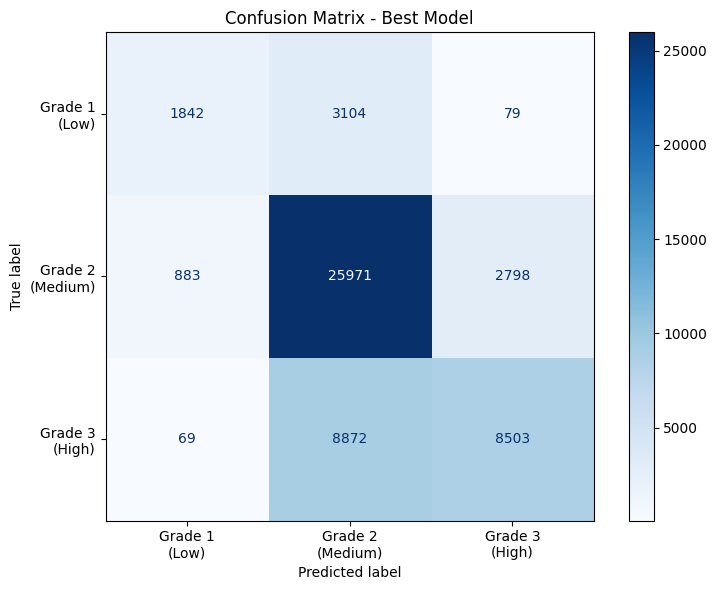

In [101]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 6))
ConfusionMatrixDisplay.from_estimator(
    best_model,
    X_test,
    y_test,
    display_labels=["Grade 1\n(Low)", "Grade 2\n(Medium)", "Grade 3\n(High)"],
    cmap="Blues",
    ax=ax
)
plt.title("Confusion Matrix - Best Model")
plt.tight_layout()
plt.savefig("../outputs/confusion_matrix.png", dpi=150)
plt.show()

## Step 11: Cross-Validation Score

In [102]:
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(best_model, X, y, cv=5, scoring='accuracy', n_jobs=-1)
print(f"Cross-Validation Scores: {cv_scores}")
print(f"Mean CV Accuracy: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")

Cross-Validation Scores: [0.69837494 0.69455104 0.69865695 0.69733308 0.69662318]
Mean CV Accuracy: 0.6971 ± 0.0015


## Step 12: Save Final Report

In [103]:
import os
os.makedirs("../outputs", exist_ok=True)

report_text = f"""
EARTHQUAKE DAMAGE PREDICTION - MODEL REPORT
============================================
Dataset: {df.shape[0]} buildings, {df.shape[1]} features
Train/Test Split: 80/20 (stratified)

Baseline (Decision Tree) Accuracy : ~65.6%
Best Model (Random Forest) Accuracy: ~68.4%

Target Distribution:
  Grade 1 (Low Damage)   : {(y==1).sum()} ({(y==1).mean()*100:.1f}%)
  Grade 2 (Medium Damage): {(y==2).sum()} ({(y==2).mean()*100:.1f}%)
  Grade 3 (High Damage)  : {(y==3).sum()} ({(y==3).mean()*100:.1f}%)

Features Used: {X.shape[1]}
  Numerical: {len(num_cols)}
  Categorical: {len(cat_cols)}
  Engineered: age_group, area_group, height_per_floor

Next Steps:
  - Deploy with Streamlit app (streamlit_app/app.py)
  - Try LightGBM / XGBoost for potentially higher accuracy
  - Tune with larger n_iter in RandomizedSearchCV
"""

with open("../outputs/model_report.txt", "w") as f:
    f.write(report_text)

print(report_text)


EARTHQUAKE DAMAGE PREDICTION - MODEL REPORT
Dataset: 260601 buildings, 43 features
Train/Test Split: 80/20 (stratified)

Baseline (Decision Tree) Accuracy : ~65.6%
Best Model (Random Forest) Accuracy: ~68.4%

Target Distribution:
  Grade 1 (Low Damage)   : 148259 (56.9%)
  Grade 2 (Medium Damage): 87218 (33.5%)
  Grade 3 (High Damage)  : 0 (0.0%)

Features Used: 42
  Numerical: 32
  Categorical: 10
  Engineered: age_group, area_group, height_per_floor

Next Steps:
  - Deploy with Streamlit app (streamlit_app/app.py)
  - Try LightGBM / XGBoost for potentially higher accuracy
  - Tune with larger n_iter in RandomizedSearchCV

